In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')
true_train_data = train_data.copy()

In [3]:
train_data.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [4]:
baseline_data = pd.read_csv('gender_submission.csv')

In [5]:
train_data.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Text(0, 0.5, 'Количество пассажиров')

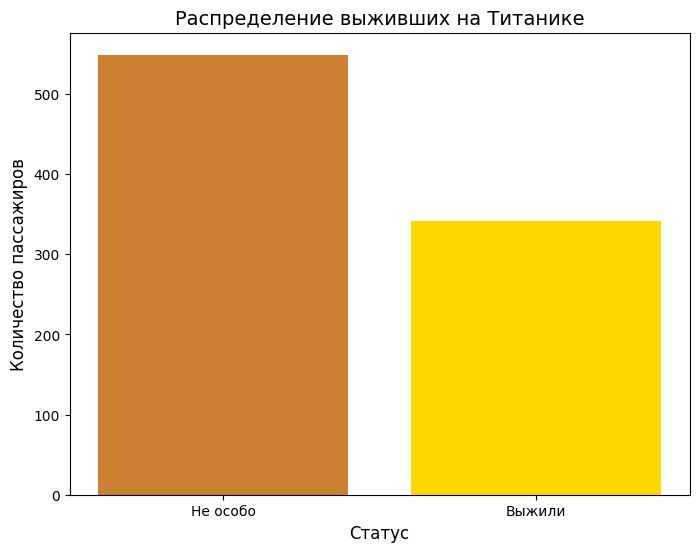

In [6]:
survival_counts = train_data['Survived'].value_counts()

plt.figure(figsize = (8, 6))
plt.bar(['Не особо', 'Выжили'], survival_counts, color = ['#CD7F32', '#FFD700'])
plt.title('Распределение выживших на Титанике', fontsize=14)
plt.xlabel('Статус', fontsize=12)
plt.ylabel('Количество пассажиров', fontsize=12)

In [7]:
train_data.groupby(['Sex', 'Survived'])['Survived'].count()

Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
Name: Survived, dtype: int64

/tmp/ipykernel_52556/2304743263.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['Мужчины', 'Женщины'], rotation=0)


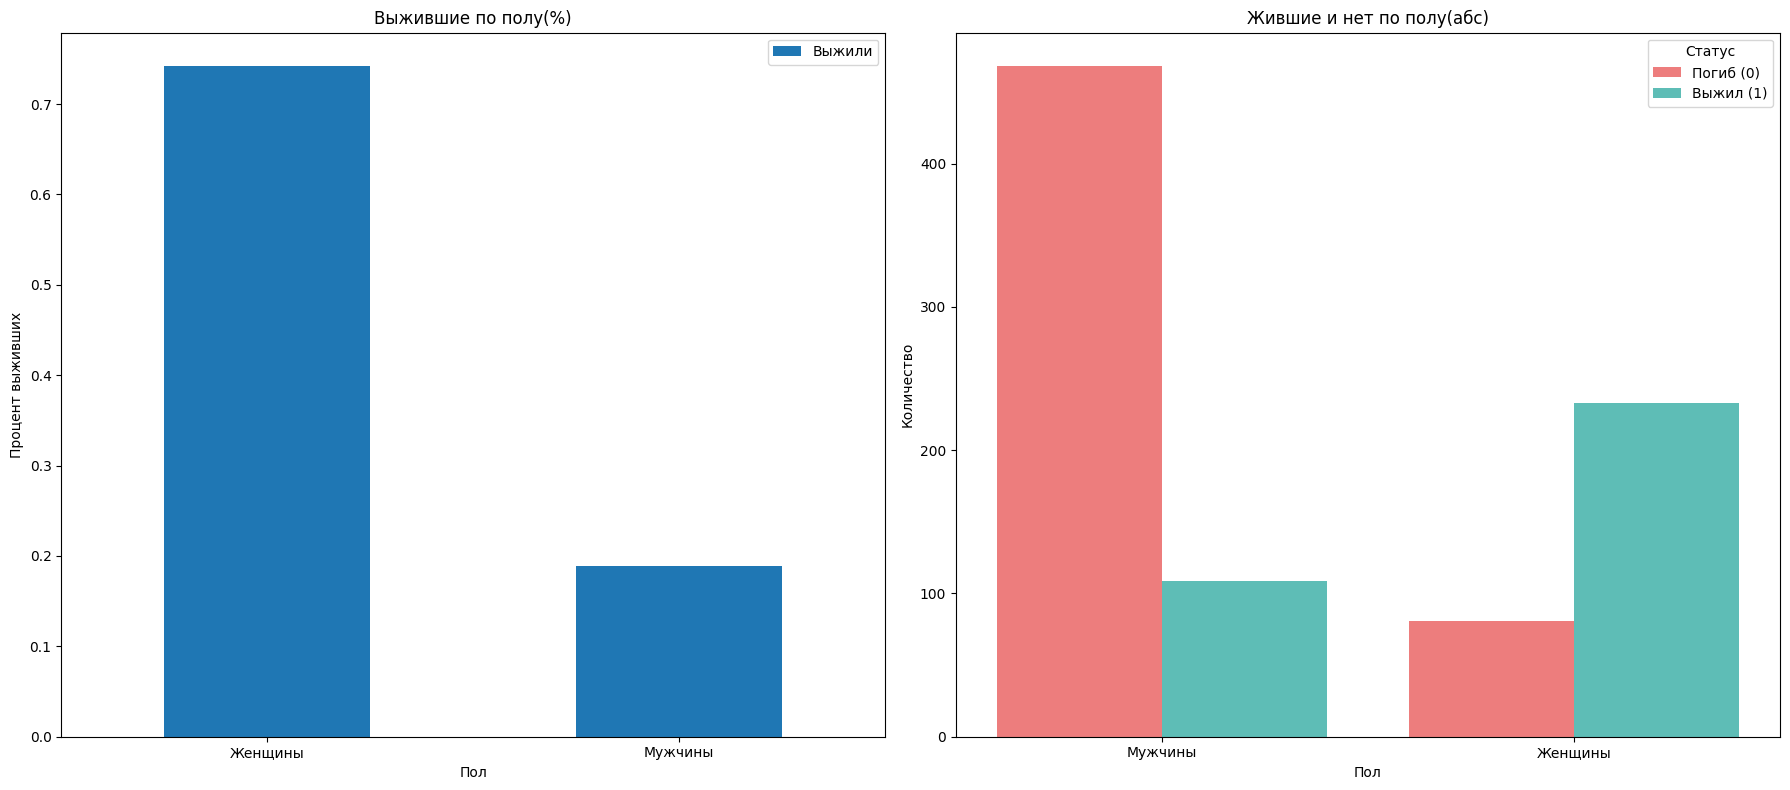

In [8]:
f, ax = plt.subplots(1, 2, figsize=(18, 8))

plot_df = train_data.copy()
plot_df = plot_df.rename(columns={'Survived': 'Выжили'})


plot_df[['Sex', 'Выжили']].groupby(['Sex']).mean().plot.bar(ax=ax[0])
ax[0].set_title('Выжившие по полу(%)')
ax[0].set_ylabel('Процент выживших')
ax[0].set_xticklabels(['Женщины', 'Мужчины'], rotation=0)
ax[0].set_xlabel('Пол')


sns.countplot(x='Sex', hue='Survived', data=train_data,
              palette=['#FF6B6B', '#4ECDC4'], ax=ax[1])
ax[1].set_title('Жившие и нет по полу(абс)')
ax[1].set_xticklabels(['Мужчины', 'Женщины'], rotation=0)
ax[1].set_xlabel('Пол')
ax[1].set_ylabel('Количество')

handles, labels = ax[1].get_legend_handles_labels()
ax[1].legend(handles, ['Погиб (0)', 'Выжил (1)'], title='Статус')

plt.tight_layout()
plt.show()



## Видно, что количество выживших женщин значительно превышает количество выживших мужчин как в абсолютном, так и в процентном соотношении

In [9]:
pd.crosstab(train_data.Pclass, train_data.Survived, margins=True).style.background_gradient(cmap = 'winter_r')

Survived,0,1,All
Pclass,,,
1,80,136,216
2,97,87,184
3,372,119,491
All,549,342,891


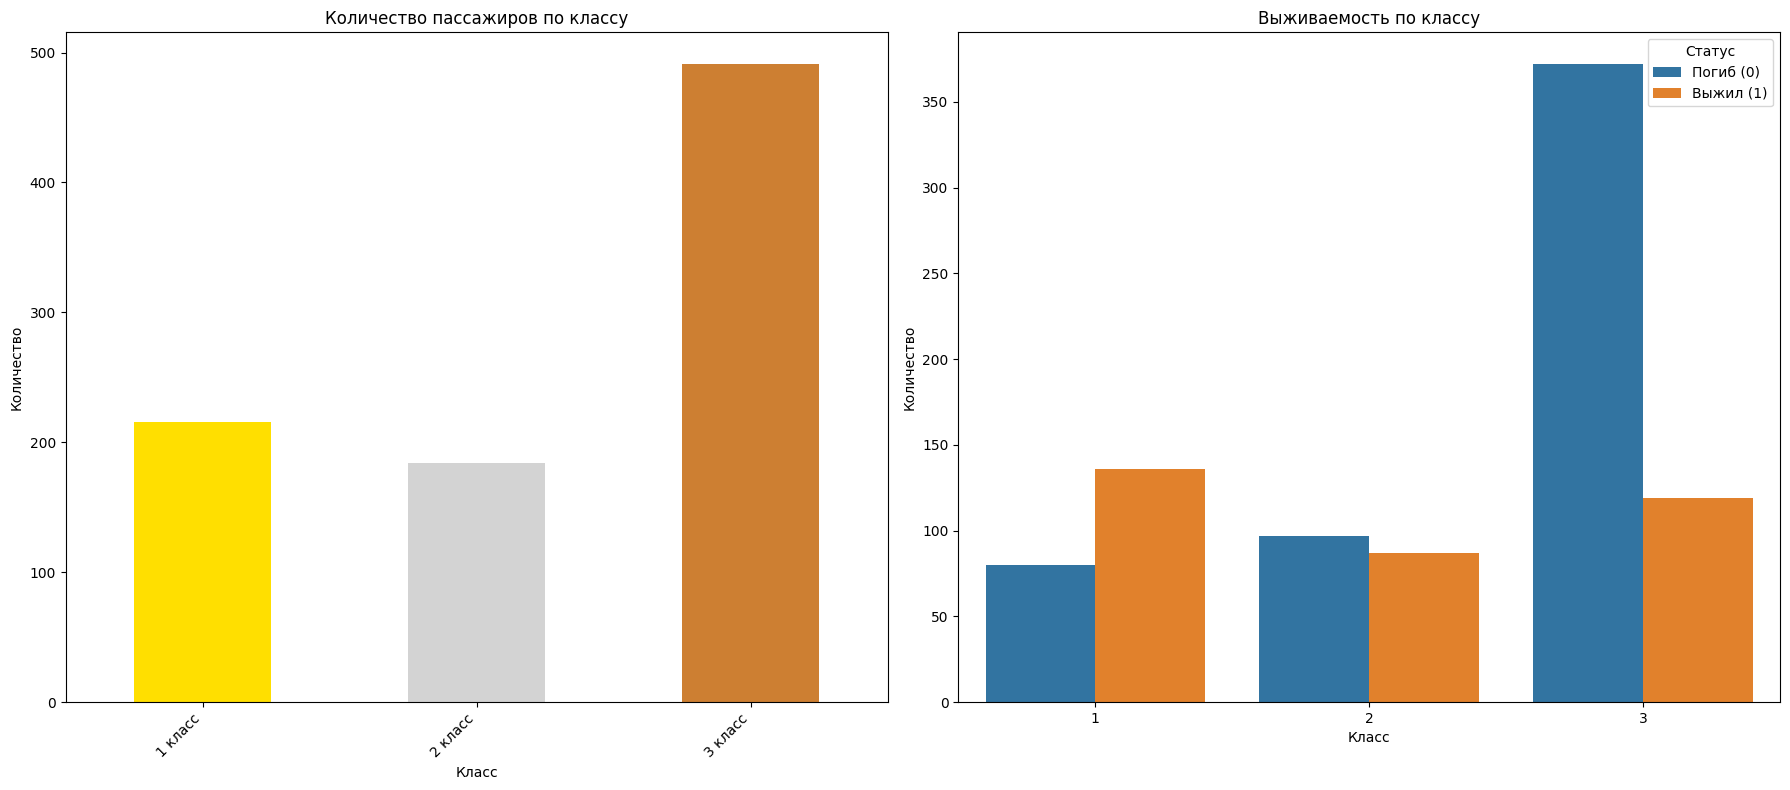

In [10]:
f, ax = plt.subplots(1, 2, figsize=(18, 8))

train_data['Pclass'].value_counts().sort_index().plot.bar(
    color=['#FFDF00', '#D3D3D3', '#CD7F32'],
    ax=ax[0]
)
ax[0].set_title('Количество пассажиров по классу')
ax[0].set_ylabel('Количество')
ax[0].set_xlabel('Класс')
ax[0].set_xticklabels(['1 класс', '2 класс', '3 класс'], rotation=45, ha='right')

sns.countplot(x='Pclass', hue='Survived', data=train_data, ax=ax[1])
ax[1].set_title('Выживаемость по классу')
ax[1].set_xlabel('Класс')
ax[1].set_ylabel('Количество')

handles, labels = ax[1].get_legend_handles_labels()
ax[1].legend(handles, ['Погиб (0)', 'Выжил (1)'], title='Статус')

plt.tight_layout()
plt.show()

## По графикам видно, что наибольшее число людей в 3 классе, наибольшая процентная вероятность выжить была у 1 класса


In [11]:
pd.crosstab([train_data.Sex,train_data.Survived],train_data.Pclass,margins=True).style.background_gradient(cmap='winter_r')

Всего 3 женщины из первого класса умерли, 6 из второго

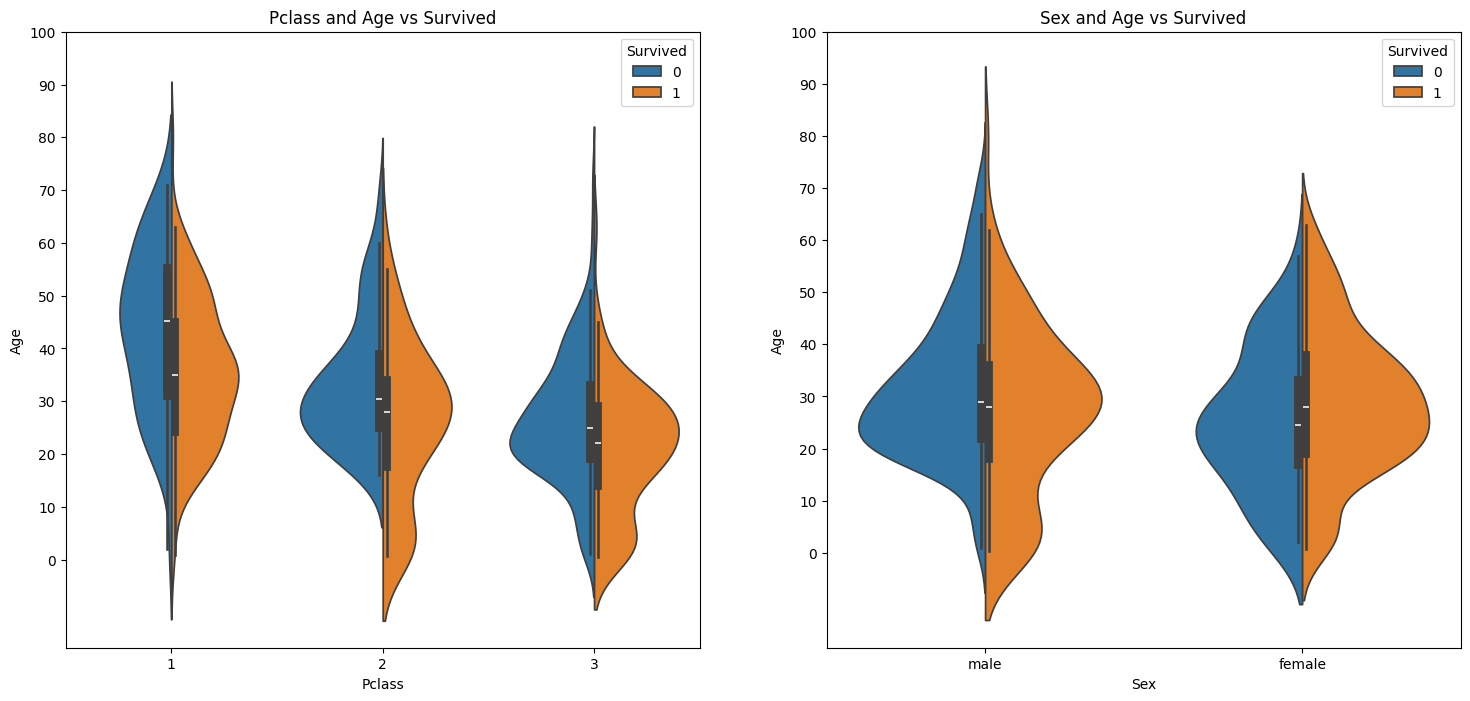

In [12]:
f, ax = plt.subplots(1, 2, figsize=(18, 8))

sns.violinplot(x="Pclass", y="Age", hue="Survived", data=train_data,
               split=True, ax=ax[0])
ax[0].set_title('Pclass and Age vs Survived')
ax[0].set_yticks(range(0, 110, 10))

sns.violinplot(x="Sex", y="Age", hue="Survived", data=train_data,
               split=True, ax=ax[1])
ax[1].set_title('Sex and Age vs Survived')
ax[1].set_yticks(range(0, 110, 10))

plt.show()

 Решаем проблему со 177 пропусками путем нахождения среднего по статусу

In [13]:

train_data['Initial'] = train_data['Name'].str.extract(r'([A-Za-z]+)\.')

In [14]:
pd.crosstab(train_data.Initial,train_data.Sex).T.style.background_gradient(cmap='winter_r')

Initial,Capt,Col,Countess,Don,Dr,Jonkheer,Lady,Major,Master,Miss,Mlle,Mme,Mr,Mrs,Ms,Rev,Sir
Sex,,,,,,,,,,,,,,,,,
female,0,0,1,0,1,0,1,0,0,182,2,1,0,125,1,0,0
male,1,2,0,1,6,1,0,2,40,0,0,0,517,0,0,6,1


In [15]:
title_mapping = {
    'Mlle': 'Miss', 'Mme': 'Mrs', 'Ms': 'Miss',
    'Dr': 'Mr', 'Major': 'Mr', 'Lady': 'Mrs',
    'Countess': 'Mrs', 'Jonkheer': 'Mr', 'Col': 'Mr',
    'Rev': 'Mr', 'Capt': 'Mr', 'Sir': 'Mr', 'Don': 'Mr'
}

train_data['Initial'] = train_data['Initial'].replace(title_mapping)

In [16]:
train_data['Initial'].value_counts()

,count
Initial,
Mr,538
Miss,185
Mrs,128
Master,40


In [17]:
for title in train_data['Initial'].unique():
    median_age = train_data[train_data['Initial'] == title]['Age'].median()
    train_data.loc[
        (train_data['Age'].isnull()) & (train_data['Initial'] == title),
        'Age'
    ] = median_age


In [18]:
train_data.groupby('Initial')['Age'].mean()



,Age
Initial,
Master,4.466750
Miss,21.681081
Mr,32.348513
Mrs,35.757812


# Создаем колонку обращений и по ее медиане заполняем пропуски в столбце с возрастом, также убираем имя и название каюты



In [19]:
train_data = train_data.drop(columns=['Name', 'Cabin'], axis = 1)

In [20]:
train_data

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Initial
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,S,Mr
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,C,Mrs
2,3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S,Miss
3,4,1,1,female,35.0,1,0,113803,53.1000,S,Mrs
4,5,0,3,male,35.0,0,0,373450,8.0500,S,Mr
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.0,0,0,211536,13.0000,S,Mr
887,888,1,1,female,19.0,0,0,112053,30.0000,S,Miss
888,889,0,3,female,21.0,1,2,W./C. 6607,23.4500,S,Miss
889,890,1,1,male,26.0,0,0,111369,30.0000,C,Mr


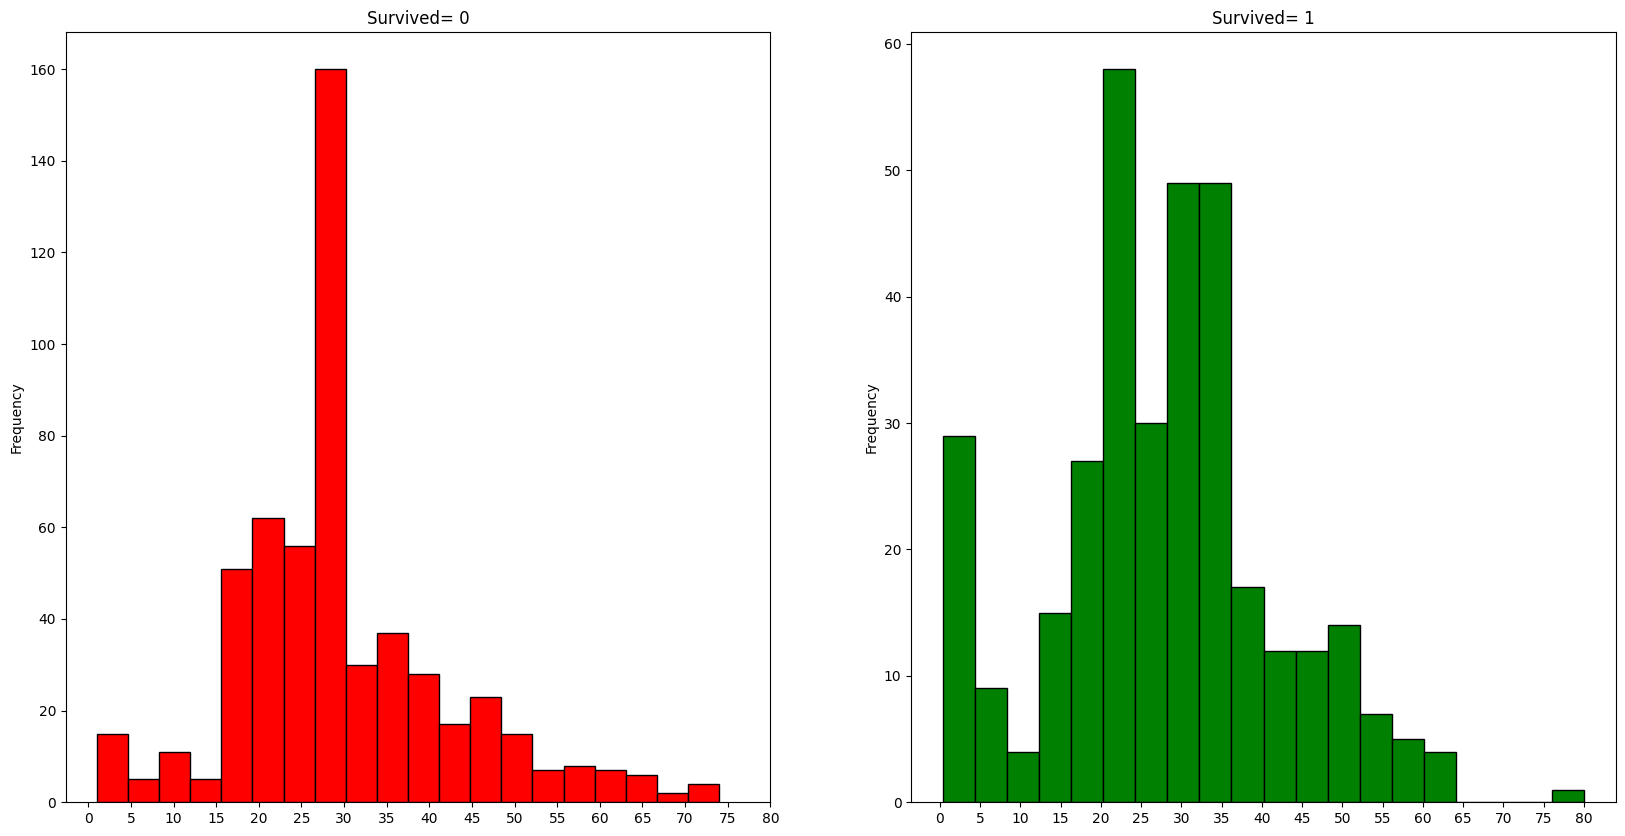

In [21]:
f,ax=plt.subplots(1,2,figsize=(20,10))
train_data[train_data['Survived']==0].Age.plot.hist(ax=ax[0],bins=20,edgecolor='black',color='red')
ax[0].set_title('Survived= 0')
x1=list(range(0,85,5))
ax[0].set_xticks(x1)
train_data[train_data['Survived']==1].Age.plot.hist(ax=ax[1],color='green',bins=20,edgecolor='black')
ax[1].set_title('Survived= 1')
x2=list(range(0,85,5))
ax[1].set_xticks(x2)
plt.show()

# Можно заметить, что дети выживали заметно чаще, в основном гибли взрослые +- 30 лет


In [22]:
pd.crosstab([train_data.Embarked,train_data.Pclass],[train_data.Sex,train_data.Survived],margins=True).style.background_gradient(cmap='winter_r')

В основном с порта Q пассажиры 3 класса


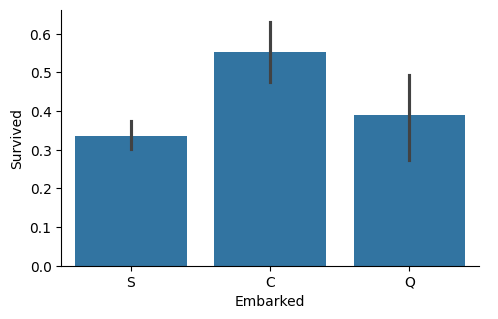

In [23]:
sns.catplot(x = 'Embarked',y = 'Survived',data=train_data, kind = 'bar')
fig=plt.gcf()
fig.set_size_inches(5,3)
plt.show()

In [24]:
train_data['Embarked'] = train_data['Embarked'].fillna('S')

Поскольку большая часть людей с порта S, дадим всем НАНам это значение

In [25]:
pd.crosstab([train_data.SibSp],train_data.Survived).style.background_gradient(cmap='winter_r')

Survived,0,1
SibSp,,
0,398,210
1,97,112
2,15,13
3,12,4
4,15,3
5,5,0
8,7,0


In [26]:
pd.crosstab(train_data.SibSp,train_data.Pclass).style.background_gradient(cmap='winter_r')

Pclass,1,2,3
SibSp,,,
0,137,120,351
1,71,55,83
2,5,8,15
3,3,1,12
4,0,0,18
5,0,0,5
8,0,0,7


#Видно, что люди с большим количеством родственников(конкретнее братьев/сестер,жены/мужья)  не выживали вообще, кроме того, они были из третьего класса

In [27]:
pd.crosstab(train_data.Parch,train_data.Pclass).style.background_gradient(cmap='winter_r')

Pclass,1,2,3
Parch,,,
0,163,134,381
1,31,32,55
2,21,16,43
3,0,2,3
4,1,0,3
5,0,0,5
6,0,0,1


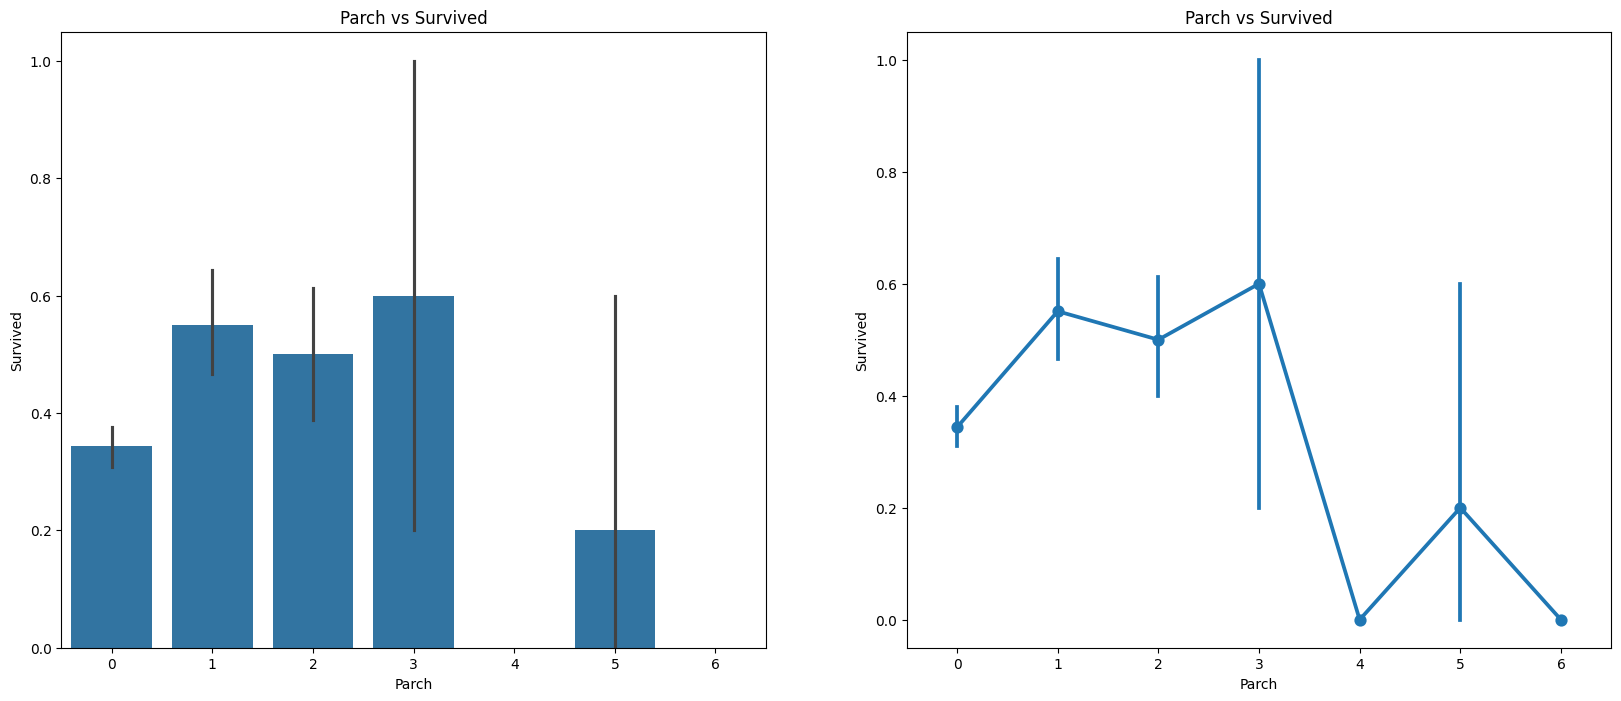

In [28]:
f,ax=plt.subplots(1,2,figsize=(20,8))
sns.barplot(x='Parch',y='Survived',data=train_data,ax=ax[0])
ax[0].set_title('Parch vs Survived')
sns.pointplot(x='Parch',y='Survived',data=train_data,ax=ax[1])
ax[1].set_title('Parch vs Survived')
plt.close(2)
plt.show()

#С небольшим количеством родителей на борту шанс выжить больше, с нулевым и большим соответственно меньше

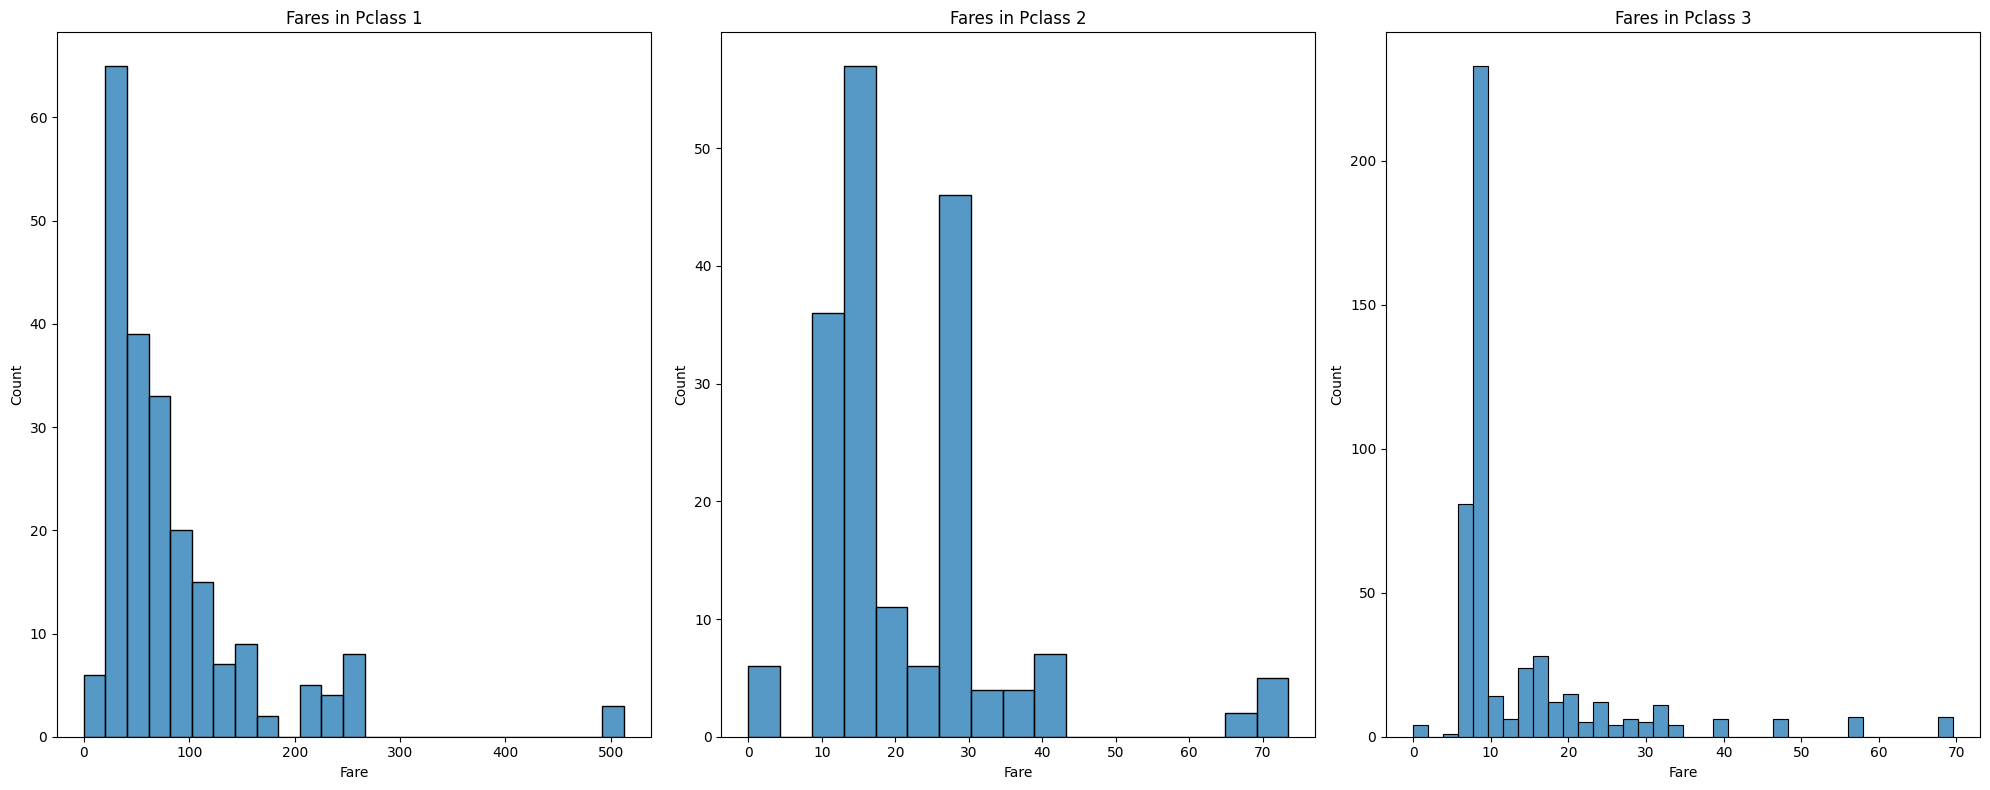

In [29]:
f, ax = plt.subplots(1, 3, figsize=(20, 8))

sns.histplot(train_data[train_data['Pclass']==1].Fare, ax=ax[0])
ax[0].set_title('Fares in Pclass 1')

sns.histplot(train_data[train_data['Pclass']==2].Fare, ax=ax[1])
ax[1].set_title('Fares in Pclass 2')

sns.histplot(train_data[train_data['Pclass']==3].Fare, ax=ax[2])
ax[2].set_title('Fares in Pclass 3')

plt.tight_layout()
plt.show()

# Предсказуемо, чем лучше класс, тем выше цена

## Итого:

*   Женщины и дети выживали чаще, по причине, того, что их положено спасать первыми
*   Чем выше класс, тем больше шанс выжить
*   Одинокие люди, и люди с большим количеством родственников выживали меньше
*   Шансы выжить людям с порта C выше

## Корреляция:

In [30]:
print("Колонки в train_data:")
print(train_data.columns.tolist())

Колонки в train_data:
['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked', 'Initial']


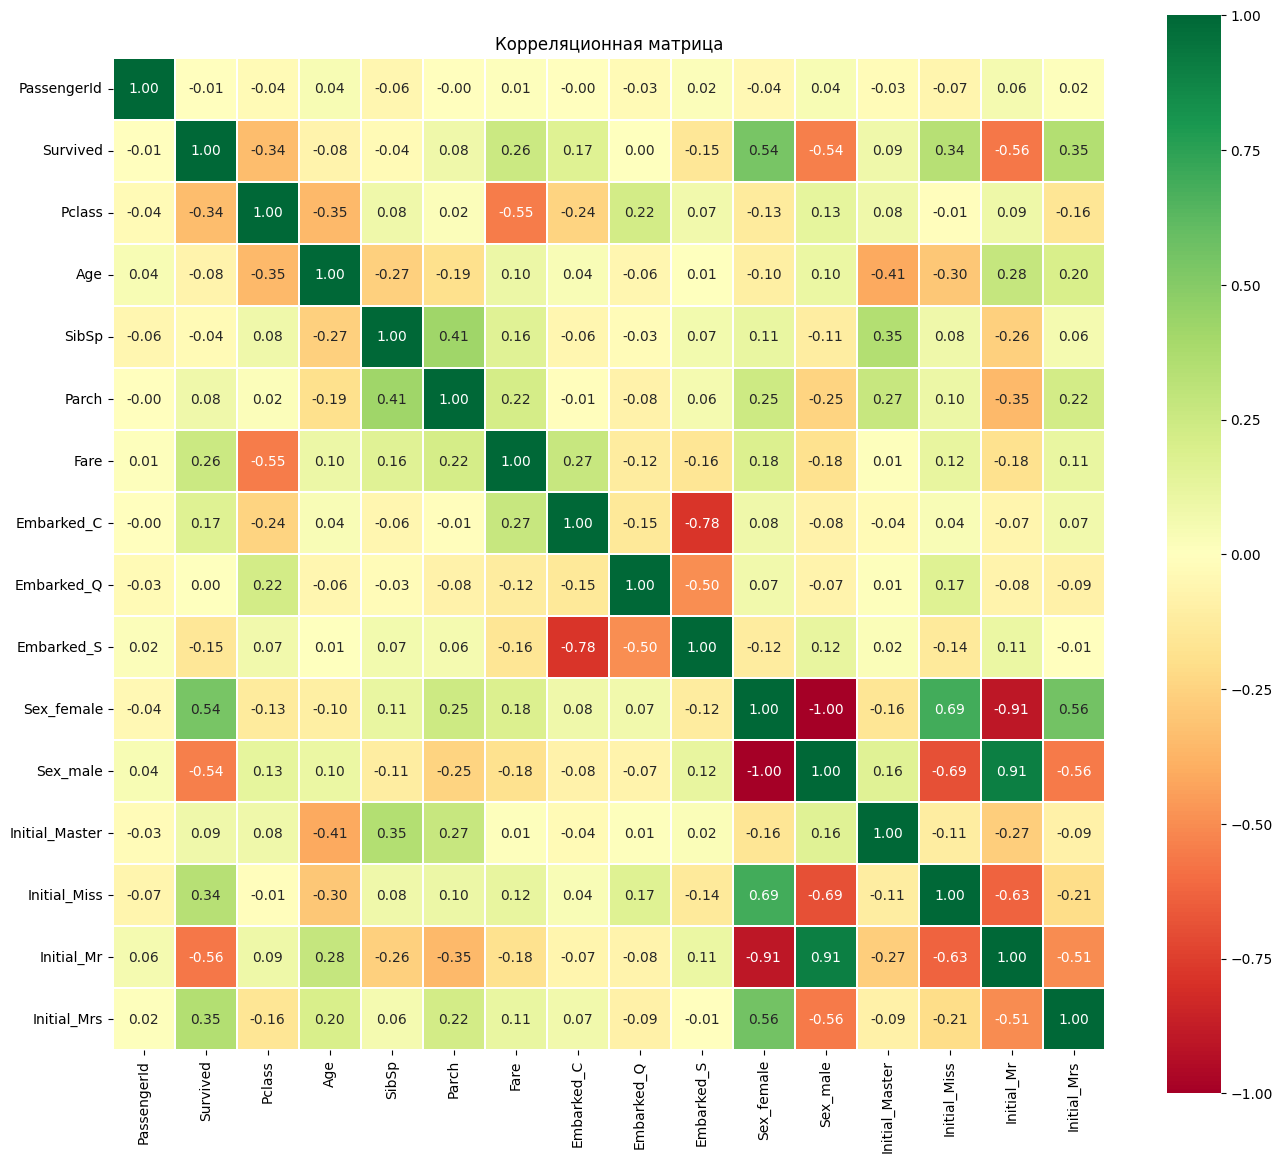

Корреляция с Survived:
Survived          1.000000
Sex_female        0.543351
Initial_Mrs       0.347864
Initial_Miss      0.335636
Fare              0.257307
Embarked_C        0.168240
Initial_Master    0.085221
Parch             0.081629
Embarked_Q        0.003650
PassengerId      -0.005007
SibSp            -0.035322
Age              -0.077786
Embarked_S       -0.149683
Pclass           -0.338481
Sex_male         -0.543351
Initial_Mr       -0.563879
Name: Survived, dtype: float64


In [31]:

corr_data = pd.get_dummies(
    train_data,
    columns=['Embarked', 'Sex', 'Initial'],
    drop_first=False
)

bool_columns = corr_data.select_dtypes(include=['bool']).columns
corr_data[bool_columns] = corr_data[bool_columns].astype(int)

numeric_data = corr_data.select_dtypes(include=['number'])

plt.figure(figsize=(16, 14))
sns.heatmap(numeric_data.corr(), annot=True, cmap='RdYlGn',
            linewidths=0.2, fmt='.2f', square=True)
plt.title('Корреляционная матрица')
plt.show()

corr_with_target = numeric_data.corr()['Survived'].sort_values(ascending=False)
print("Корреляция с Survived:")
print(corr_with_target)

# Инжиниринг фичей

In [56]:
#сделать инициалы, убрать имя и каюту, (превратить первые три цифры билета в класс), ohe для многоклассовых, разбить возраст по группам, сделать размер семьи, проверка на одиночку
def get_frequent_tickets(df, min_count=10):
    """Возвращает список частых типов билетов"""
    ticket_types = df['Ticket'].apply(
        lambda x: x.split()[0] if isinstance(x, str) else 'Unknown'
    )
    ticket_counts = ticket_types.value_counts()
    return ticket_counts[ticket_counts >= min_count].index.tolist()


def preprocessing(df: pd.DataFrame, frequent_tickets: list) -> pd.DataFrame:
  df = df.copy()

  df['Initial'] = df['Name'].str.extract(r'([A-Za-z]+)\.')
  title_mapping = {
    'Mlle': 'Miss', 'Mme': 'Mrs', 'Ms': 'Miss',
    'Dr': 'Mr', 'Major': 'Mr', 'Lady': 'Mrs',
    'Countess': 'Mrs', 'Jonkheer': 'Mr', 'Col': 'Mr',
    'Rev': 'Mr', 'Capt': 'Mr', 'Sir': 'Mr', 'Don': 'Mr'
 }
  df['Initial'] = df['Initial'].replace(title_mapping)

  df['Ticket_type'] = df['Ticket'].apply(
        lambda x: x.split()[0] if isinstance(x, str) else 'Unknown'
  )
  df['Ticket_type'] = df['Ticket_type'].apply(
        lambda x: x if x in frequent_tickets else 'Other'
  )





  title_medians = df.groupby('Initial')['Age'].median()



  for title, median_age in title_medians.items():
      df.loc[(df['Age'].isnull()) & (df['Initial'] == title), 'Age'] = median_age


  age_bins = [0, 12, 18, 35, 60, 100]
  age_labels = ['Child', 'Teen', 'Young_Adult', 'Adult', 'Senior']
  df['Age_Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)

  df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
  df['IsAlone'] = (df['FamilySize'] == 1).astype(int)


  df['Pclass'] = df['Pclass'].astype(str)

  categorical_cols = ['Age_Group', 'Ticket_type', 'Initial', 'Embarked', 'Sex', 'Pclass']
  df = pd.get_dummies(df, columns=categorical_cols, drop_first=False)

  bool_columns = df.select_dtypes(include=['bool']).columns
  df[bool_columns] = df[bool_columns].astype(int)


  df = df.drop(columns=['Name', 'Cabin', 'Age', 'Ticket', 'SibSp', 'Parch'], axis=1)

  return df

In [64]:
frequent_tickets = get_frequent_tickets(true_train_data)
df1 = preprocessing(true_train_data, frequent_tickets)
df1

,PassengerId,Survived,Fare,FamilySize,IsAlone,Age_Group_Child,Age_Group_Teen,Age_Group_Young_Adult,Age_Group_Adult,Age_Group_Senior,...,Initial_Mr,Initial_Mrs,Embarked_C,Embarked_Q,Embarked_S,Sex_female,Sex_male,Pclass_1,Pclass_2,Pclass_3
0,1,0,7.2500,2,0,0,0,1,0,0,...,1,0,0,0,1,0,1,0,0,1
1,2,1,71.2833,2,0,0,0,0,1,0,...,0,1,1,0,0,1,0,1,0,0
2,3,1,7.9250,1,1,0,0,1,0,0,...,0,0,0,0,1,1,0,0,0,1
3,4,1,53.1000,2,0,0,0,0,1,0,...,0,1,0,0,1,1,0,1,0,0
4,5,0,8.0500,1,1,0,0,0,1,0,...,1,0,0,0,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,13.0000,1,1,0,0,1,0,0,...,1,0,0,0,1,0,1,0,1,0
887,888,1,30.0000,1,1,0,0,1,0,0,...,0,0,0,0,1,1,0,1,0,0
888,889,0,23.4500,4,0,0,0,1,0,0,...,0,0,0,0,1,1,0,0,0,1
889,890,1,30.0000,1,1,0,0,1,0,0,...,1,0,1,0,0,0,1,1,0,0
